In [11]:
# Cell 1: Import necessary libraries
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import sys # For sys.float_info.epsilon if needed, though 1e-6 is usually fine

# Configure plot style (optional, for better visuals in notebook)
# plt.style.use('seaborn-v0_8-whitegrid')
# %matplotlib inline # Uncomment if plots aren't showing inline

In [13]:
# Cell 2: Define the Meta-Heuristic Hybrid Optimizer with Memory
class HybridPowerFlowOptimizer:
    def __init__(self, A_matrix, line_limits, memory_size=100, max_sum_diff=4.0):
        self.A = A_matrix
        # Ensure line limits are stored as float64 for consistency
        self.line_limits = np.array(line_limits, dtype=np.float64)
        self.memory = deque(maxlen=memory_size)  # Memory of successful solutions
        self.num_buses = A_matrix.shape[1]
        self.max_sum_diff = max_sum_diff  # Maximum allowed sum of differences
        # Keep tolerance for float comparisons (e.g., sum diff, balance) small
        self.tolerance = 1e-6
        self.original_B_ref = None # To store original B for fitness calcs

    def optimize(self, B, iterations=200, population_size=30, alpha=0.7):
        self.original_B_ref = B.copy()
        similar_solution = self._check_memory(B)
        if similar_solution is not None:
            print("Using solution from memory as starting point")
            initial_population = [similar_solution.copy() for _ in range(population_size//2)]
            initial_population.extend([self._generate_random_solution(B) for _ in range(population_size - len(initial_population))]) # Fill rest
        else:
            initial_population = [self._generate_random_solution(B) for _ in range(population_size)]

        # Ensure the original B is in the population (or a close variant)
        initial_population[0] = B.copy()
        initial_population[0] -= np.mean(initial_population[0]) # Balance it immediately

        best_solution = initial_population[0].copy() # Start with a balanced version of B
        best_fitness = self._calculate_fitness(best_solution, B, alpha)

        fitness_history = []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}

        for iteration in range(iterations):
            if iteration < iterations * 0.3: weights = [0.2, 0.6, 0.2]
            elif iteration < iterations * 0.7: weights = [0.3, 0.3, 0.4]
            else: weights = [0.6, 0.2, 0.2]

            new_population = []
            for i in range(population_size):
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]
                if algorithm == 'OOA':
                    new_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['OOA'] += 1
                elif algorithm == 'KHA':
                    new_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['KHA'] += 1
                else: # SHO
                    new_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    algorithm_contributions['SHO'] += 1

                new_solution -= np.mean(new_solution) # Ensure power balance
                new_population.append(new_solution)
                fitness = self._calculate_fitness(new_solution, B, alpha)
                sum_diff = np.sum(np.abs(new_solution - B))

                # Update best if fitness is lower AND sum_diff constraint met (using tolerance)
                if fitness < best_fitness and sum_diff <= self.max_sum_diff + self.tolerance:
                    best_fitness = fitness
                    best_solution = new_solution.copy()
                    # Debug print (optional)
                    # if iteration % 20 == 0 and i == 0:
                    #     print(f"Iter {iteration}: New best fit={best_fitness:.4f}, Sum diff={sum_diff:.4f}")

            initial_population = new_population
            fitness_history.append(best_fitness)

        best_solution -= np.mean(best_solution) # Final balance check
        print("\nApplying final minimization step...")
        best_solution = self._minimize_changes(best_solution, B) # Minimize changes post-optimization

        # Store if feasible according to the 2-decimal rule AND sum_diff met
        if self._is_feasible(best_solution):
             final_sum_diff_for_memory = np.sum(np.abs(best_solution - B))
             if final_sum_diff_for_memory <= self.max_sum_diff + self.tolerance:
                  self._store_in_memory(B, best_solution)
             else:
                  print(f"Warning: Feasible solution found ({final_sum_diff_for_memory:.4f}) but exceeds final sum_diff limit ({self.max_sum_diff:.4f}) after minimization, not storing.")
        else:
             print("Warning: Final solution is not feasible (by 2-decimal rule), not storing in memory.")

        total = sum(algorithm_contributions.values())
        if total > 0:
            print("\nAlgorithm Contributions:")
            for algo, count in algorithm_contributions.items(): print(f"{algo}: {count/total*100:.1f}%")

        final_sum_diff = np.sum(np.abs(best_solution - B))
        print(f"\nFinal sum of differences: {final_sum_diff:.4f} (Target Max: {self.max_sum_diff:.4f})")

        return best_solution, fitness_history, np.dot(self.A, best_solution)

    def _minimize_changes(self, solution, original_B, steps=100, initial_step_factor=0.1):
        """Minimize changes while maintaining feasibility (2-decimal rule) and sum_diff limit."""
        best_solution = solution.copy()
        best_sum_diff = np.sum(np.abs(best_solution - original_B))
        print(f"Starting minimization. Initial sum_diff: {best_sum_diff:.4f}")
        current_max_sum_diff = self.max_sum_diff

        for current_step in range(steps):
            step_factor = initial_step_factor * (1 - current_step / steps)**2
            direction = original_B - best_solution
            if np.linalg.norm(direction) < self.tolerance:
                print("Solution is already very close to original B.")
                break

            new_solution_attempt = best_solution + step_factor * direction
            new_solution_attempt -= np.mean(new_solution_attempt) # Balance
            actual_sum_diff = np.sum(np.abs(new_solution_attempt - original_B))

            # Check feasibility using 2-decimal rule AND sum_diff limit
            if self._is_feasible(new_solution_attempt) and actual_sum_diff <= current_max_sum_diff + self.tolerance:
                # Check if it's actually closer (smaller sum_diff, using tolerance)
                if actual_sum_diff < best_sum_diff - self.tolerance:
                    best_solution = new_solution_attempt.copy()
                    best_sum_diff = actual_sum_diff
                    # print(f"Min Step {current_step}: New sum_diff: {actual_sum_diff:.4f}") # Verbose debug
            # else: # If step failed, could try smaller step, but keep simple for now
                # pass

        final_sum_diff = np.sum(np.abs(best_solution - original_B))
        print(f"Finished minimization. Final sum_diff: {final_sum_diff:.4f}")
        best_solution -= np.mean(best_solution) # Final balance check
        return best_solution

    def _generate_random_solution(self, B):
        """Generate a random solution based on B respecting sum diff constraint"""
        max_attempts = 10
        mean_abs_B = np.mean(np.abs(B))
        if mean_abs_B < self.tolerance: mean_abs_B = 1.0 # Avoid division by zero

        for attempt in range(max_attempts):
            # Smaller perturbation relative to mean absolute value or a fixed small value
            perturbation_scale = max(0.01, 0.1 * mean_abs_B)
            random_solution = B.copy() + np.random.uniform(-perturbation_scale, perturbation_scale, size=B.shape)
            random_solution -= np.mean(random_solution) # Ensure power balance

            sum_diff = np.sum(np.abs(random_solution - B))
            # Check against instance's limit using tolerance
            if sum_diff <= self.max_sum_diff + self.tolerance:
                return random_solution

        # Fallback if no suitable random solution found
        print(f"Warning: Could not generate random solution within sum_diff limit ({self.max_sum_diff:.4f}) after {max_attempts} attempts. Returning minimally perturbed.")
        random_solution = B.copy() + np.random.uniform(-0.01, 0.01, size=B.shape) * (mean_abs_B if mean_abs_B > 0 else 1.0)
        random_solution -= np.mean(random_solution)
        return random_solution

    def _calculate_fitness(self, solution, original_B, alpha=0.7):
        """Calculate fitness. Uses full precision internally for penalties."""
        C = np.dot(self.A, solution)
        # Calculate violation based on unrounded flows vs limits + tolerance
        # Penalties should reflect the actual numerical violation to guide the search
        violations = np.maximum(0, np.abs(C.flatten()) - (self.line_limits + self.tolerance))
        violation_penalty = 100 * np.sum(violations**2) # Penalize large violations heavily

        norm_B = np.linalg.norm(original_B)
        if norm_B < self.tolerance: norm_B = 1.0
        # Deviation penalty based on full precision difference
        deviation_penalty = np.linalg.norm(solution - original_B) / norm_B

        sum_diff = np.sum(np.abs(solution - original_B))
        # Sum diff penalty based on full precision difference vs limit + tolerance
        sum_diff_penalty = 100 * max(0, sum_diff - (self.max_sum_diff + self.tolerance))

        base_cost = np.sum(np.abs(C.flatten())) # Optional: minimize total absolute flow

        # Combine: Prioritize constraint violation penalties
        fitness = violation_penalty + sum_diff_penalty + alpha * deviation_penalty * 10 + (1-alpha)*0.01*base_cost
        return fitness

    def _is_feasible(self, solution):
        """
        Check if a solution is feasible.
        Line constraints: Checks if ABSOLUTE flow ROUNDED to 2 decimal places <= limit.
        Power balance: Checks if sum is close to zero using small tolerance.
        """
        if solution is None: return False

        C = np.dot(self.A, solution)
        flows = C.flatten()

        # ***MODIFIED CHECK***: Round absolute flows to 2 decimal places
        rounded_abs_flows = np.round(np.abs(flows), 2)

        # Compare rounded absolute flows to the original line limits
        # We add a small tolerance to the limit side for robustness in comparison
        # e.g., rounded flow 0.50 should be <= limit 0.50
        line_constraints_met = np.all(rounded_abs_flows <= self.line_limits + self.tolerance)

        # Power balance check: Use small tolerance, NOT rounding
        balance_met = abs(np.sum(solution)) < self.tolerance * len(solution)

        if not balance_met:
            print(f"Debug: Balance check failed, sum={np.sum(solution):.8f}") # Debug print

        return line_constraints_met and balance_met

    def _check_memory(self, B):
        """Check memory. Uses 2-decimal feasibility rule."""
        if not self.memory: return None
        best_match = None
        best_similarity = float('inf')
        norm_B = np.linalg.norm(B); similarity_threshold = 0.2 * norm_B if norm_B > self.tolerance else 0.2

        for initial_B_mem, optimal_B_mem in self.memory:
            similarity = np.linalg.norm(initial_B_mem - B)
            # Check feasibility using the current problem's constraints and the 2-decimal rule
            is_feasible_now = self._is_feasible(optimal_B_mem)
            sum_diff_now = np.sum(np.abs(optimal_B_mem - B))

            # Use memory if similar initial B, and stored optimal is feasible NOW and meets current sum_diff limit
            if similarity < similarity_threshold and is_feasible_now and sum_diff_now <= self.max_sum_diff + self.tolerance:
                if similarity < best_similarity:
                    best_similarity = similarity
                    best_match = optimal_B_mem

        if best_match is not None:
            print("Using a solution from memory.")
            return best_match
        return None

    def _store_in_memory(self, initial_B, optimal_B):
        """Store successful solution in memory"""
        self.memory.append((initial_B.copy(), optimal_B.copy()))
        print(f"Solution stored in memory. Memory size: {len(self.memory)}")

    # --- OOA, KHA, SHO implementations (No changes needed here for 2-decimal logic) ---
    def _apply_orcas_optimization(self, population, index, best_solution, iteration, max_iterations):
        solution = population[index].copy(); a = 2*(1-iteration/max_iterations); r1, r2 = random.random(), random.random()
        if random.random() < 0.5:
            dist=np.abs(best_solution-solution); b=1; l=2*r1-1; new_solution=dist*np.exp(b*l)*np.cos(2*np.pi*l)+best_solution
        else:
            rand_idx=random.choice(range(len(population))); X_rand=population[rand_idx]; A=2*a*r2-a; C=2*r1; D=np.abs(C*X_rand-solution); new_solution=X_rand-A*D
        return new_solution

    def _apply_krill_herd(self, population, index, best_solution, iteration, max_iterations):
        solution=population[index].copy(); Vf=0.02; Nmax=0.01; Dt=1
        Ni=Nmax*(best_solution-solution); Fi=Vf*(best_solution-solution); delta=np.random.uniform(-1,1,solution.shape); Dmax=0.005*(1-iteration/max_iterations); Di=Dmax*delta
        return solution + Dt*(Ni+Fi+Di)

    def _apply_spotted_hyena(self, population, index, best_solution, iteration, max_iterations):
        solution = population[index].copy(); h = 5 - iteration*(5/max_iterations); B=2*random.random(); E = 2*h*random.random()-h
        D_best = np.abs(B*best_solution-solution); X1 = best_solution - E*D_best
        if abs(E)>=1: rand_h=random.choice(population); D_h=np.abs(B*rand_h-solution); new_solution=rand_h-E*D_h
        else: new_solution=X1
        return new_solution

In [15]:
# Cell 3: Define helper functions for orchestration

def optimize_power_flow(A, B, line_limits, iterations=200, alpha=0.7, max_sum_diff=4.0):
    """Wrapper function to instantiate and run the optimizer."""
    optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=max_sum_diff)
    C_unoptimized = np.dot(A, B)
    B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations, alpha=alpha)
    return B_optimized, fitness_history, C_optimized, C_unoptimized

def find_minimum_sum_diff(A, B, line_limits, alpha=0.7, start_sum_diff=0.0,
                          max_attempts=100, min_step_size=1e-5, initial_iterations=200):
    """Incrementally find the minimum sufficient max_sum_diff, using 2-decimal feasibility check."""
    print("Starting incremental search for minimum sum difference...")
    # Keep internal tolerance small for float comparisons
    tolerance = 1e-6
    current_sum_diff = start_sum_diff
    attempt = 0
    best_feasible_solution_data = None
    best_feasible_sum_diff_achieved = float('inf')
    C_unoptimized = np.dot(A, B)

    # Check if initial B is already feasible using the 2-decimal rule
    temp_optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=float('inf'))
    if temp_optimizer._is_feasible(B):
        actual_sum_diff = np.sum(np.abs(B - B)) # Should be 0
        print("Initial power injections already satisfy all constraints (using 2-decimal rule)!")
        return B, [], C_unoptimized, C_unoptimized, actual_sum_diff

    mean_abs_B = np.mean(np.abs(B)); mean_abs_B = max(mean_abs_B, 1.0) # Ensure > 0
    current_step_size = max(min_step_size, mean_abs_B * 0.001) # Adaptive step
    print(f"Using initial adaptive step size: {current_step_size:.6f}")

    last_failing_max_sum_diff = None; first_success_max_sum_diff = None

    # --- Phase 1: Linear Search Upwards ---
    print("\n--- Phase 1: Searching for first feasible max_sum_diff ---")
    while attempt < max_attempts:
        attempt += 1
        print(f"\nAttempt {attempt}: Testing max_sum_diff = {current_sum_diff:.6f}")
        try:
            optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=current_sum_diff)
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=initial_iterations, alpha=alpha)
            # Use the 2-decimal feasibility check
            is_feasible = optimizer._is_feasible(B_optimized)
            actual_sum_diff = np.sum(np.abs(B_optimized - B))

            # Check if feasible (by 2-decimal rule) AND respects the tested max_sum_diff limit (using tolerance)
            if is_feasible and actual_sum_diff <= current_sum_diff + tolerance:
                print(f"✓ FEASIBLE solution found with actual sum_diff = {actual_sum_diff:.6f} (limit {current_sum_diff:.6f})")
                if actual_sum_diff < best_feasible_sum_diff_achieved:
                    best_feasible_solution_data = (B_optimized, fitness_history, C_optimized)
                    best_feasible_sum_diff_achieved = actual_sum_diff
                first_success_max_sum_diff = current_sum_diff
                print(f"First successful max_sum_diff threshold found: {first_success_max_sum_diff:.6f}")
                break # Go to Phase 2
            else:
                feasibility_msg = "FEASIBLE" if is_feasible else "INFEASIBLE (by 2-dec rule)"
                limit_msg = "within limit" if actual_sum_diff <= current_sum_diff + tolerance else f"exceeds limit ({actual_sum_diff:.6f} > {current_sum_diff:.6f})"
                print(f"✗ Solution is {feasibility_msg} and {limit_msg}")
                last_failing_max_sum_diff = current_sum_diff
                current_sum_diff += current_step_size
        except Exception as e:
            print(f"Error during optimization at max_sum_diff={current_sum_diff:.6f}: {e}")
            last_failing_max_sum_diff = current_sum_diff
            current_sum_diff += current_step_size # Increase limit and retry

    # --- Phase 2: Binary Search ---
    if first_success_max_sum_diff is not None:
        print(f"\n--- Phase 2: Binary search between {last_failing_max_sum_diff if last_failing_max_sum_diff is not None else 0.0:.6f} and {first_success_max_sum_diff:.6f} ---")
        low = last_failing_max_sum_diff if last_failing_max_sum_diff is not None else 0.0
        high = first_success_max_sum_diff

        for bs_iter in range(25): # Binary search iterations for precision
            mid = (low + high) / 2
            if high - low < min_step_size / 10: # Stop if range is tiny
                print("Binary search range too small, stopping.")
                break

            print(f"Binary Search Iter {bs_iter+1}: Testing max_sum_diff = {mid:.6f}")
            try:
                optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=mid)
                B_opt, fit_hist, C_opt = optimizer.optimize(B, iterations=initial_iterations, alpha=alpha)
                is_feasible = optimizer._is_feasible(B_opt) # Use 2-decimal check
                actual_sum = np.sum(np.abs(B_opt - B))

                # Check feasibility (2-dec rule) AND if achieved sum_diff is within tested limit 'mid' (using tolerance)
                if is_feasible and actual_sum <= mid + tolerance:
                    print(f"✓ Binary search FOUND feasible with actual sum_diff = {actual_sum:.6f}")
                    high = mid # Try even lower max_sum_diff
                    # Store if this is the best *achieved* sum_diff so far
                    if actual_sum < best_feasible_sum_diff_achieved:
                        best_feasible_solution_data = (B_opt, fit_hist, C_opt)
                        best_feasible_sum_diff_achieved = actual_sum
                else:
                    feasibility_msg = "FEASIBLE" if is_feasible else "INFEASIBLE (by 2-dec rule)"
                    limit_msg = "within limit" if actual_sum <= mid + tolerance else f"exceeds limit ({actual_sum:.6f} > {mid:.6f})"
                    print(f"✗ Binary search FAILED ({feasibility_msg}, {limit_msg}) at max_sum_diff = {mid:.6f}")
                    low = mid # Need to allow more max_sum_diff
            except Exception as e:
                print(f"Error during binary search optimization at max_sum_diff={mid:.6f}: {e}")
                low = mid # Assume failure

    # --- Return results ---
    if best_feasible_solution_data is not None:
        print(f"\nOptimal feasible solution found with achieved sum_diff = {best_feasible_sum_diff_achieved:.6f}")
        B_optimized, fitness_history, C_optimized = best_feasible_solution_data
        return B_optimized, fitness_history, C_optimized, C_unoptimized, best_feasible_sum_diff_achieved
    else:
        print("\nFailed to find any feasible solution within the maximum attempts.")
        # Fallback: Run one last time with a large max_sum_diff
        print("Running one last time with large max_sum_diff=10.0 as fallback.")
        optimizer = HybridPowerFlowOptimizer(A, line_limits, max_sum_diff=100.0)
        try:
            B_optimized, fitness_history, C_optimized = optimizer.optimize(B, iterations=initial_iterations, alpha=alpha)
            final_sum_diff = np.sum(np.abs(B_optimized - B))
            # Still check feasibility using the 2-decimal rule for the returned solution
            if optimizer._is_feasible(B_optimized):
                 print("Fallback optimization found a feasible solution (by 2-dec rule).")
            else:
                 print("Warning: Fallback optimization did NOT find a feasible solution (by 2-dec rule).")
            return B_optimized, fitness_history, C_optimized, C_unoptimized, final_sum_diff
        except Exception as e:
            print(f"Error in final optimization attempt: {e}")
            return B, [], C_unoptimized, C_unoptimized, np.inf # Indicate failure

In [17]:
# Cell 4: Define the function for visualizing results with 2-decimal focus
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, fitness_history, optimal_sum_diff):
    num_lines = A.shape[0]
    num_buses = A.shape[1]
    # Keep small tolerance for internal checks if needed elsewhere, but primary check is 2-dec rounding
    tolerance = 1e-6

    # --- Plots (No changes needed in plotting logic itself) ---
    plt.figure(figsize=(12, 6))
    line_indices = range(1, num_lines + 1)
    plt.plot(line_indices, C_unoptimized.flatten(), marker='o', linestyle='-', label='Unoptimized Flows', alpha=0.7)
    plt.plot(line_indices, C_optimized.flatten(), marker='s', linestyle='--', label='Optimized Flows', alpha=0.9)
    plt.plot(line_indices, line_limits, color='r', linestyle=':', alpha=0.8, label='Limit (+)')
    plt.plot(line_indices, -line_limits, color='r', linestyle=':', alpha=0.8, label='Limit (-)')

    # Highlight violations based on the 2-decimal rule for consistency
    # Calculate rounded flows for plotting violations accurately
    rounded_abs_flows_opt = np.round(np.abs(C_optimized.flatten()), 2)
    violations = np.where(rounded_abs_flows_opt > line_limits + tolerance)[0]
    if len(violations) > 0:
        violated_indices = violations + 1
        # Plot the actual unrounded flow where violation occurred
        violated_flows = C_optimized.flatten()[violations]
        plt.scatter(violated_indices, violated_flows, color='magenta', s=100, zorder=5, label='Violations (Optimized)')

    plt.xlabel('Line Index'); plt.ylabel('Power Flow'); plt.title('Power Flow Comparison (Limits Applied at 2 Decimals)')
    plt.legend(); plt.grid(True, which='both', linestyle='--', linewidth=0.5); plt.xticks(line_indices); plt.tight_layout(); plt.show()

    if fitness_history and len(fitness_history) > 0:
        plt.figure(figsize=(10, 5)); plt.plot(range(len(fitness_history)), fitness_history, marker='.', linestyle='-', color='b', label='Best Fitness Score')
        plt.xlabel('Iteration'); plt.ylabel('Fitness Score (Log Scale)'); plt.title('Fitness Score Convergence')
        plt.yscale('log'); plt.legend(); plt.grid(True, which='both', linestyle='--', linewidth=0.5); plt.tight_layout(); plt.show()

    plt.figure(figsize=(12, 6)); bus_indices = np.arange(1, num_buses + 1); bar_width = 0.35
    plt.bar(bus_indices - bar_width/2, B.flatten(), width=bar_width, label='Initial Injections', alpha=0.7, color='blue')
    plt.bar(bus_indices + bar_width/2, B_optimized.flatten(), width=bar_width, label='Optimized Injections', alpha=0.7, color='green')
    plt.xlabel('Bus Index'); plt.ylabel('Power Injection'); plt.title('Bus Power Injection Comparison')
    plt.xticks(bus_indices); plt.legend(); plt.grid(True, axis='y', linestyle='--', linewidth=0.5); plt.tight_layout(); plt.show()

    plt.figure(figsize=(10, 5)); changes = B_optimized.flatten() - B.flatten(); colors = ['green' if x >= 0 else 'red' for x in changes]
    plt.bar(range(1, num_buses + 1), changes, color=colors); plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Bus Index'); plt.ylabel('Injection Change (Optimized - Initial)'); plt.title('Difference Between Optimized and Initial Injections')
    plt.xticks(range(1, num_buses + 1)); plt.grid(True, axis='y', linestyle='--', linewidth=0.5); plt.tight_layout(); plt.show()

    # --- Print Results (Formatted to 2 decimal places) ---
    abs_changes = np.abs(changes)
    abs_original = np.abs(B.flatten())
    pct_changes = np.zeros_like(abs_changes)
    non_zero_mask = abs_original > tolerance
    pct_changes[non_zero_mask] = abs_changes[non_zero_mask] / abs_original[non_zero_mask] * 100
    avg_pct_change = np.mean(pct_changes[non_zero_mask]) if np.any(non_zero_mask) else 0.0
    final_sum_diff_report = np.sum(abs_changes)
    norm_B = np.linalg.norm(B); norm_B = max(norm_B, tolerance) # Avoid div by zero
    relative_deviation = np.linalg.norm(changes)/norm_B*100

    # Set numpy print options for arrays
    np.set_printoptions(precision=2, suppress=True)

    print("\n" + "="*30 + " RESULTS (2 Decimal Focus) " + "="*30)
    # Format array printing using the options set above
    print("\nLine Limits ({}x1):\n".format(num_lines), line_limits)
    print("\nInitial Power Injections (B, {}x1):\n".format(num_buses), B.flatten())
    print("\nResultant Line Flows Before Optimization ({}x1):\n".format(num_lines), C_unoptimized.flatten())
    print("\n" + "-"*70)
    print("\nOptimized Power Injections (B_optimized, {}x1):\n".format(num_buses), B_optimized.flatten())
    # Use f-string for specific precision on scalar values
    print(f"Sum of Optimized Power Injections (Should be near 0): {np.sum(B_optimized):.6f}") # Show more precision for sum check
    print("\nResultant Line Flows After Optimization ({}x1):\n".format(num_lines), C_optimized.flatten())
    print("-"*70)
    print("\nChanges to Power Injections:")
    print(f"  Sum of Absolute Changes (Optimal Found): {final_sum_diff_report:.2f}") # Display sum diff with 2 decimals
    print(f"  Average Percentage Change (for non-zero initial): {avg_pct_change:.2f}%")
    print(f"  Relative Deviation (L2 Norm): {relative_deviation:.2f}%")

    print("\nConstraint Check (Based on Flows Rounded to 2 Decimals):")
    # Re-check using the specific 2-decimal rule for reporting
    rounded_abs_flows_final = np.round(np.abs(C_optimized.flatten()), 2)
    # Use small tolerance when comparing rounded flow vs limit
    violations_final_report = np.where(rounded_abs_flows_final > line_limits + tolerance)[0]

    if len(violations_final_report) > 0:
        print(f"  WARNING: {len(violations_final_report)} line constraints violated (when flow rounded to 2 decimals)!")
        for line_idx in violations_final_report:
            # Show the rounded flow, the limit, and the unrounded flow for context
            rounded_flow = rounded_abs_flows_final[line_idx]
            limit = line_limits[line_idx]
            actual_flow = C_optimized.flatten()[line_idx] # Unrounded flow
            # Show violation amount with more precision
            exceeds_by = rounded_flow - limit
            print(f"    Line {line_idx+1}: Flow (Rounded) = {rounded_flow:.2f}, Limit = {limit:.2f}, Exceeds by = {exceeds_by:.6f} (Actual Flow: {actual_flow:.6f})")
    else:
        print("  All line constraints satisfied (when flows rounded to 2 decimals).")

    total_flow_unopt = np.sum(np.abs(C_unoptimized))
    total_flow_opt = np.sum(np.abs(C_optimized))
    print("\nTotal Absolute Line Power Flow:")
    print(f"  Before Optimization: {total_flow_unopt:.2f}")
    print(f"  After Optimization:  {total_flow_opt:.2f}")
    if abs(total_flow_unopt) > tolerance:
      print(f"  Percentage Difference: {((total_flow_opt - total_flow_unopt)/total_flow_unopt)*100:.2f}%")
    print("="*70)


==================== New Power Flow Scenario ====================

Enter power limits for each of the 7 lines (e.g., 0.50):


Enter absolute power limit for Line 1:  100
Enter absolute power limit for Line 2:  50
Enter absolute power limit for Line 3:  50
Enter absolute power limit for Line 4:  50
Enter absolute power limit for Line 5:  50
Enter absolute power limit for Line 6:  50
Enter absolute power limit for Line 7:  50



Enter power injections for each of the 5 buses (e.g., -1.50, 0.75):


Enter power injection for Bus 1:  147
Enter power injection for Bus 2:  36
Enter power injection for Bus 3:  -31
Enter power injection for Bus 4:  -80
Enter power injection for Bus 5:  -72


Initial power injections sum (0.0000) is close to zero.



Enter alpha value (weight for minimal changes, 0.0-1.0, e.g., 0.7-0.95):  1



Starting incremental optimization...
Starting incremental search for minimum sum difference...
Using initial adaptive step size: 0.073200

--- Phase 1: Searching for first feasible max_sum_diff ---

Attempt 1: Testing max_sum_diff = 0.000000

Applying final minimization step...
Starting minimization. Initial sum_diff: 0.0000
Solution is already very close to original B.
Finished minimization. Final sum_diff: 0.0000

Algorithm Contributions:
OOA: 36.0%
KHA: 36.2%
SHO: 27.8%

Final sum of differences: 0.0000 (Target Max: 0.0000)
✗ Solution is INFEASIBLE (by 2-dec rule) and within limit

Attempt 2: Testing max_sum_diff = 0.073200

Applying final minimization step...
Starting minimization. Initial sum_diff: 0.0730
Finished minimization. Final sum_diff: 0.0730

Algorithm Contributions:
OOA: 35.6%
KHA: 36.2%
SHO: 28.1%

Final sum of differences: 0.0730 (Target Max: 0.0732)
✗ Solution is INFEASIBLE (by 2-dec rule) and within limit

Attempt 3: Testing max_sum_diff = 0.146400

Applying final m

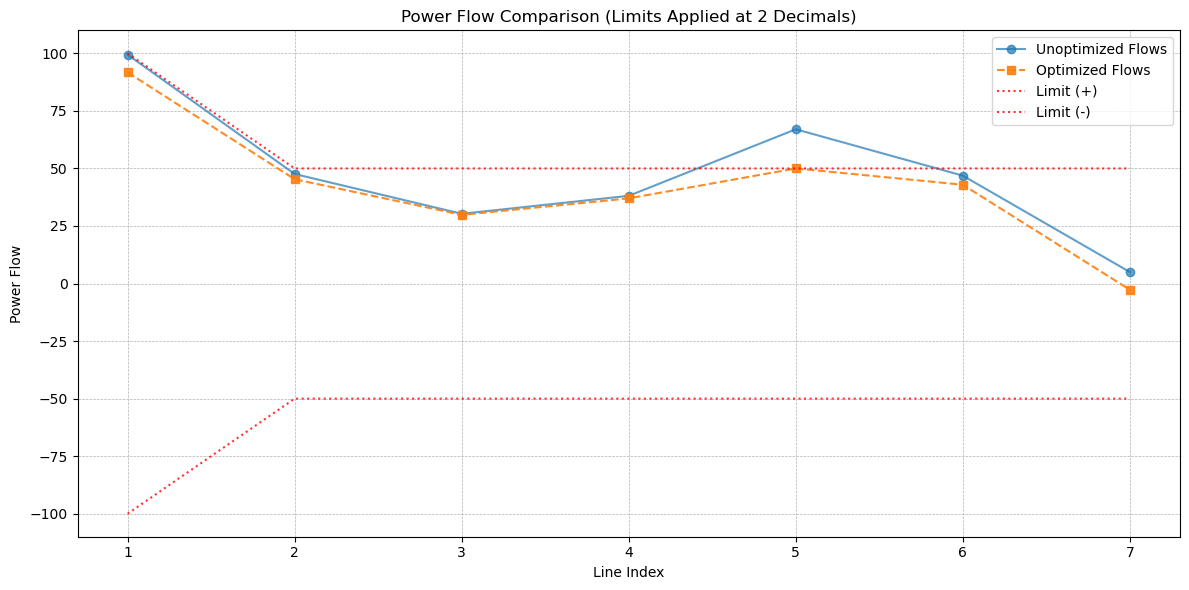

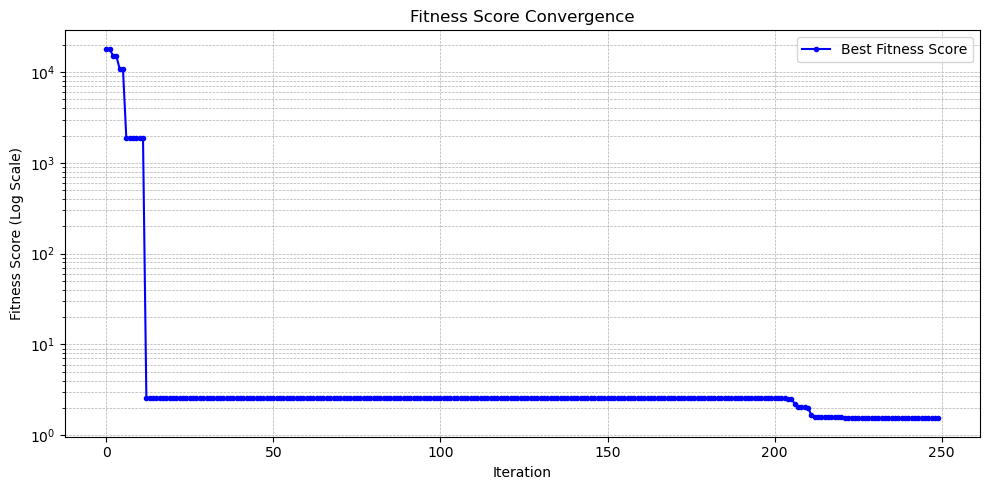

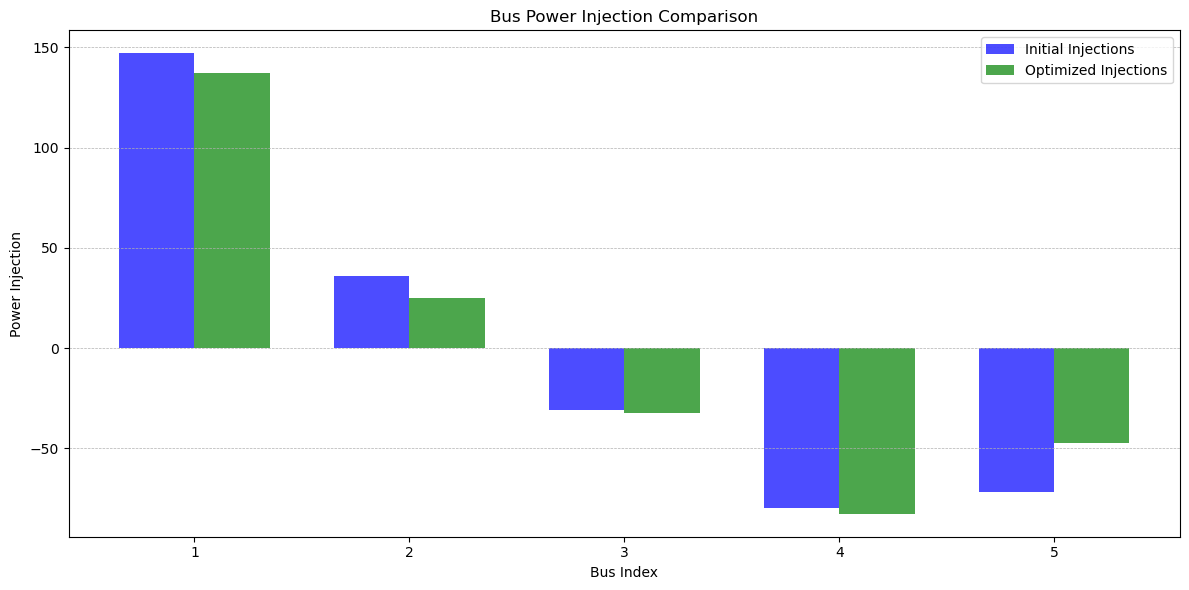

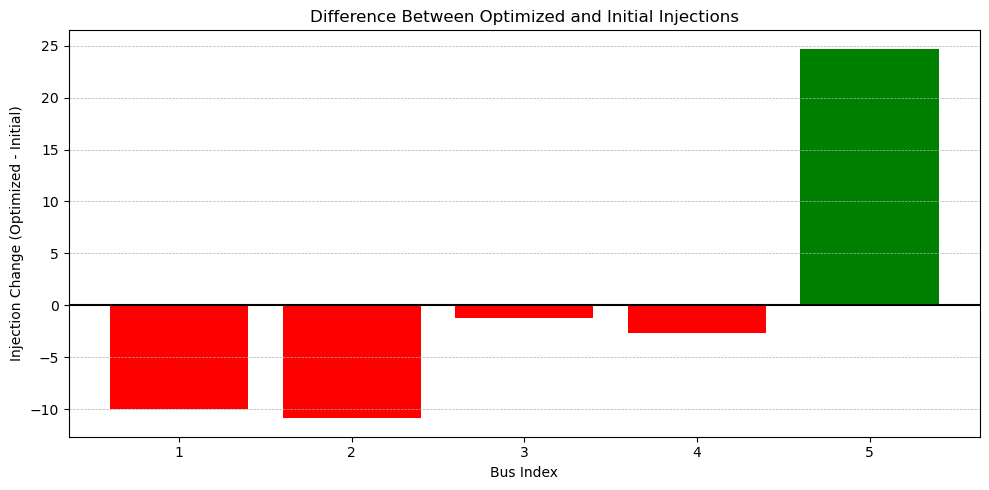


============================== RESULTS (2 Decimal Focus) ==============================

Line Limits (7x1):
 [100.  50.  50.  50.  50.  50.  50.]

Initial Power Injections (B, 5x1):
 [147.  36. -31. -80. -72.]

Resultant Line Flows Before Optimization (7x1):
 [99.43 47.57 30.29 38.11 67.02 46.86  4.98]

----------------------------------------------------------------------

Optimized Power Injections (B_optimized, 5x1):
 [137.04  25.13 -32.24 -82.62 -47.3 ]
Sum of Optimized Power Injections (Should be near 0): 0.000000

Resultant Line Flows After Optimization (7x1):
 [91.72 45.31 29.85 37.   50.   42.91 -2.7 ]
----------------------------------------------------------------------

Changes to Power Injections:
  Sum of Absolute Changes (Optimal Found): 49.40
  Average Percentage Change (for non-zero initial): 15.71%
  Relative Deviation (L2 Norm): 15.36%

Constraint Check (Based on Flows Rounded to 2 Decimals):
  All line constraints satisfied (when flows rounded to 2 decimals).

Total

In [ ]:
# Cell 5: Main execution block for running scenarios

# Define the fixed 7x5 matrix A
A = np.array([
    [0.5857, -0.2571, -0.0428, -0.0857, -0.2000],
    [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
    [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
    [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
    [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
    [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
    [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
])
num_lines_main = A.shape[0]
num_buses_main = A.shape[1]

# Loop for running multiple scenarios
while True:
    print("\n" + "="*20 + " New Power Flow Scenario " + "="*20)

    # --- User Input ---
    print(f"\nEnter power limits for each of the {num_lines_main} lines (e.g., 0.50):")
    try:
        line_limits_input = np.array([float(input(f"Enter absolute power limit for Line {i+1}: ")) for i in range(num_lines_main)])
        if np.any(line_limits_input < 0):
            print("Warning: Line limits should be non-negative. Using absolute values.")
            line_limits_input = np.abs(line_limits_input)
    except ValueError:
        print("Invalid input. Please enter numeric values for line limits.")
        continue

    print(f"\nEnter power injections for each of the {num_buses_main} buses (e.g., -1.50, 0.75):")
    try:
        B_input_list = [float(input(f"Enter power injection for Bus {i+1}: ")) for i in range(num_buses_main)]
        B_input = np.array(B_input_list).reshape(num_buses_main, 1)
        initial_sum = np.sum(B_input)
        # Use slightly larger tolerance for user input sum check, format output
        if abs(initial_sum) > 1e-3:
            print(f"\nWarning: Initial power injections sum to {initial_sum:.2f}, which is not zero.") # Format output
            print("The algorithm will enforce balance (sum=0) by adjusting injections.")
        else:
            print(f"Initial power injections sum ({initial_sum:.4f}) is close to zero.") # Show more detail if close
    except ValueError:
        print("Invalid input. Please enter numeric values for bus injections.")
        continue

    while True:
        try:
            alpha_input = float(input("\nEnter alpha value (weight for minimal changes, 0.0-1.0, e.g., 0.7-0.95): "))
            if 0.0 <= alpha_input <= 1.0: break
            else: print("Alpha must be between 0.0 and 1.0.")
        except ValueError: print("Invalid input. Please enter a numeric value for alpha.")

    # --- Run Optimization ---
    print("\nStarting incremental optimization...")
    B_optimized, fitness_history, C_optimized, C_unoptimized, optimal_sum_diff = find_minimum_sum_diff(
        A, B_input, line_limits_input, alpha=alpha_input, initial_iterations=250
    )

    print("\n" + "="*20 + " Optimization Complete " + "="*20)
    if optimal_sum_diff == np.inf:
         print("Optimization failed to find a feasible solution (by 2-dec rule).")
    else:
        # Format output of optimal sum diff
        print(f"Minimum required sum of differences found/used: {optimal_sum_diff:.2f}")

        # --- Visualize Results (using updated function) ---
        print("\nVisualizing optimization results...")
        visualize_results(A, B_input, B_optimized, C_optimized, C_unoptimized, line_limits_input,
                          fitness_history, optimal_sum_diff=optimal_sum_diff)

        # --- Save Results (Optional, with updated formatting) ---
        save_results = input("\nDo you want to save the detailed results to a file? (y/n): ").strip().lower()
        if save_results == 'y':
            default_filename = "power_flow_results_2dec.txt" # Updated default name
            filename = input(f"Enter filename (default: {default_filename}): ").strip() or default_filename
            try:
                with open(filename, 'w') as f:
                    f.write("Power Flow Optimization Results (2 Decimal Focus)\n")
                    f.write("="*30 + "\n\n")
                    f.write(f"Matrix A ({num_lines_main}x{num_buses_main}):\n")
                    np.savetxt(f, A, fmt='%.4f') # Keep reasonable precision for A
                    f.write("\nLine Power Limits:\n")
                    for i, limit in enumerate(line_limits_input): f.write(f"Line {i+1}: {limit:.2f}\n") # 2 decimals
                    f.write("\nInitial Power Injections (B):\n")
                    for i, injection in enumerate(B_input): f.write(f"Bus {i+1}: {injection[0]:.2f}\n") # 2 decimals
                    f.write("\nOptimized Power Injections (B_optimized):\n")
                    for i, injection in enumerate(B_optimized): f.write(f"Bus {i+1}: {injection[0]:.2f}\n") # 2 decimals
                    f.write("\nResultant Line Flows Before Optimization (C_unoptimized):\n")
                    for i, flow in enumerate(C_unoptimized): f.write(f"Line {i+1}: {flow[0]:.2f}\n") # 2 decimals
                    f.write("\nResultant Line Flows After Optimization (C_optimized):\n")
                    for i, flow in enumerate(C_optimized): f.write(f"Line {i+1}: {flow[0]:.2f}\n") # 2 decimals
                    f.write(f"\nMinimum Required Sum of Differences (Achieved): {optimal_sum_diff:.4f}\n") # More precision for sum diff

                    # Constraint check in file (using 2-decimal rule)
                    rounded_flows_file = np.round(np.abs(C_optimized.flatten()), 2)
                    violations_file = np.where(rounded_flows_file > line_limits_input + 1e-6)[0] # Use tolerance
                    if len(violations_file) > 0:
                        f.write(f"\nWarning: {len(violations_file)} line constraints violated (when flow rounded to 2 decimals)!\n")
                        for line in violations_file:
                             f.write(f"  Line {line+1}: Flow (Rounded) = {rounded_flows_file[line]:.2f}, Limit = {line_limits_input[line]:.2f}\n")
                    else:
                        f.write("\nAll line constraints satisfied (when flows rounded to 2 decimals).\n")

                    f.write("\nOptimization Parameters:\n")
                    f.write(f"Alpha: {alpha_input:.2f}\n")
                print(f"Results successfully saved to {filename}")
            except IOError as e: print(f"Error saving results to {filename}: {e}")

    # --- Repeat? ---
    run_again = input("\nDo you want to run another scenario? (y/n): ").strip().lower()
    if run_again != 'y':
        print("\nExiting...")
        break
    else:
        print("\nRestarting...\n")